In [1]:
# importing dataset using pandas  
import pandas as pd
 
# to do numerical operations    
import numpy as np

# setting directory using os
import os

In [2]:
# importing dataset
data = os.chdir(r"C:\Users\Welcome\Downloads")
data = pd.read_csv('Airlines.csv')

In [3]:
data

,FFP#,AwardMiles,EliteMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans,EnrollDuration
0,1,28143,0,174,1,0,0,7000
1,2,19244,0,215,2,0,0,6968
2,3,41354,0,4123,4,0,0,7034
3,4,14776,0,500,1,0,0,6952
4,5,97752,0,43300,26,2077,4,6935
...,...,...,...,...,...,...,...,...
3994,4017,18476,0,8525,4,200,1,1403
3995,4018,64385,0,981,5,0,0,1395
3996,4019,73597,0,25447,8,0,0,1402
3997,4020,54899,0,500,1,500,1,1401


In [4]:
# to know the information of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   FFP#                3999 non-null   int64
 1   AwardMiles          3999 non-null   int64
 2   EliteMiles          3999 non-null   int64
 3   PartnerMiles        3999 non-null   int64
 4   PartnerTrans        3999 non-null   int64
 5   FlyingReturnsMiles  3999 non-null   int64
 6   FlightTrans         3999 non-null   int64
 7   EnrollDuration      3999 non-null   int64
dtypes: int64(8)
memory usage: 250.1 KB


In [5]:
# cheching the distribution of the variables
data.describe()

,FFP#,AwardMiles,EliteMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans,EnrollDuration
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000
mean,2014.819455,7.360133e+04,144.114529,17144.846212,11.60190,460.055764,1.373593,4118.55939
std,1160.764358,1.007757e+05,773.663804,24150.967826,9.60381,1400.209171,3.793172,2065.13454
min,1.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,2.00000
25%,1010.500000,1.852750e+04,0.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000
50%,2016.000000,4.309700e+04,0.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000
75%,3020.500000,9.240400e+04,0.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000
max,4021.000000,1.704838e+06,11148.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000


In [6]:
# checking for duplicates
len(data[data.duplicated()])

0

In [7]:
data.drop(labels = 'FFP#', axis = 1, inplace = True)
data.tail()

,AwardMiles,EliteMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans,EnrollDuration
3994,18476,0,8525,4,200,1,1403
3995,64385,0,981,5,0,0,1395
3996,73597,0,25447,8,0,0,1402
3997,54899,0,500,1,500,1,1401
3998,3016,0,0,0,0,0,1398


In [8]:
# changing 'Awardmiles' as proper number
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
data.describe()

,AwardMiles,EliteMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans,EnrollDuration
count,3999.000,3999.000,3999.000,3999.000,3999.000,3999.000,3999.000
mean,73601.328,144.115,17144.846,11.602,460.056,1.374,4118.559
std,100775.665,773.664,24150.968,9.604,1400.209,3.793,2065.135
min,0.000,0.000,0.000,0.000,0.000,0.000,2.000
25%,18527.500,0.000,1250.000,3.000,0.000,0.000,2330.000
50%,43097.000,0.000,7171.000,12.000,0.000,0.000,4096.000
75%,92404.000,0.000,23800.500,17.000,311.000,1.000,5790.500
max,1704838.000,11148.000,263685.000,86.000,30817.000,53.000,8296.000


In [1]:
data['EliteMiles'].value_counts()

NameError: name 'data' is not defined

In [10]:
# importing seaborn to view the plots to check the outliers
import seaborn as sns

# importing library to create 2D graphs and plots
import matplotlib.pyplot as plt

<AxesSubplot:ylabel='AwardMiles'>

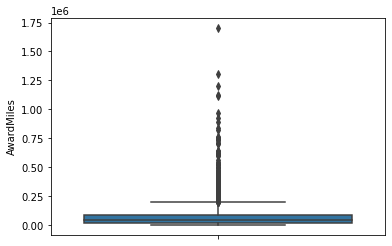

In [11]:
sns.boxplot(y=data['AwardMiles'])

In [12]:
# Capping the outliers
Q1 = data["AwardMiles"].quantile(0.25)
Q3 = data["AwardMiles"].quantile(0.75)
IQR = Q3 - Q1
out_ls=[]
for i in data["AwardMiles"]:
    if(i<Q1-(1.5*IQR)):
        i=Q1-(1.5*IQR)
        out_ls.append(i)
    elif (i>Q3+(1.5*IQR)):
        i=Q3+(1.5*IQR)
        out_ls.append(i)
    else:
        out_ls.append(i)

In [13]:
# Dropping the original column which had outliers and adding a new column with the capped values for the outliers.

data=data.drop(columns=["AwardMiles"])
data["AwardMiles"]=out_ls

<AxesSubplot:ylabel='AwardMiles'>

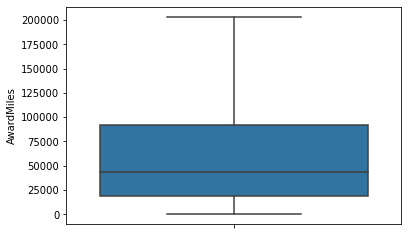

In [14]:
sns.boxplot(y=data['AwardMiles'])

<AxesSubplot:ylabel='EliteMiles'>

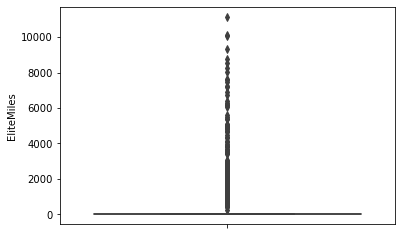

In [15]:
sns.boxplot(y=data['EliteMiles'])

<AxesSubplot:ylabel='PartnerMiles'>

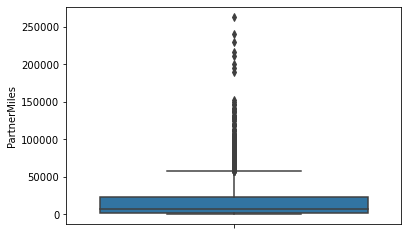

In [16]:
sns.boxplot(y=data['PartnerMiles'])

In [17]:
# Capping the outliers
Q1 = data["PartnerMiles"].quantile(0.25)
Q3 = data["PartnerMiles"].quantile(0.75)
IQR = Q3 - Q1
out_ls=[]
for i in data["PartnerMiles"]:
    if(i<Q1-(1.5*IQR)):
        i=Q1-(1.5*IQR)
        out_ls.append(i)
    elif (i>Q3+(1.5*IQR)):
        i=Q3+(1.5*IQR)
        out_ls.append(i)
    else:
        out_ls.append(i)

In [18]:
# Dropping the original column which had outliers and adding a new column with the capped values for the outliers.

data=data.drop(columns=["PartnerMiles"])
data["PartnerMiles"]=out_ls

<AxesSubplot:ylabel='PartnerMiles'>

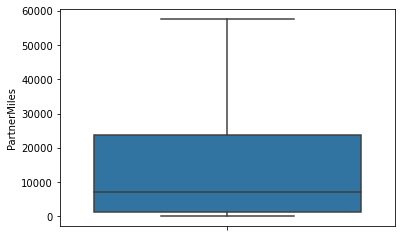

In [19]:
sns.boxplot(y=data['PartnerMiles'])

<AxesSubplot:ylabel='PartnerTrans'>

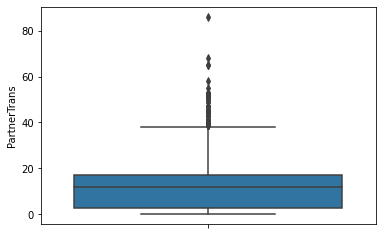

In [20]:
sns.boxplot(y=data['PartnerTrans'])

In [21]:
# Capping the outliers
Q1 = data["PartnerTrans"].quantile(0.25)
Q3 = data["PartnerTrans"].quantile(0.75)
IQR = Q3 - Q1
out_ls=[]
for i in data["PartnerTrans"]:
    if(i<Q1-(1.5*IQR)):
        i=Q1-(1.5*IQR)
        out_ls.append(i)
    elif (i>Q3+(1.5*IQR)):
        i=Q3+(1.5*IQR)
        out_ls.append(i)
    else:
        out_ls.append(i)

In [22]:
# Dropping the original column which had outliers and adding a new column with the capped values for the outliers.

data=data.drop(columns=["PartnerTrans"])
data["PartnerTrans"]=out_ls

<AxesSubplot:ylabel='PartnerTrans'>

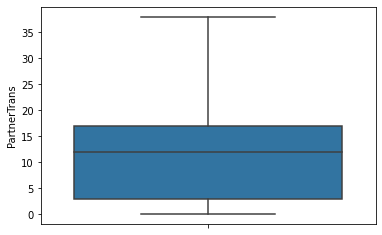

In [23]:
sns.boxplot(y=data['PartnerTrans'])

<AxesSubplot:ylabel='FlyingReturnsMiles'>

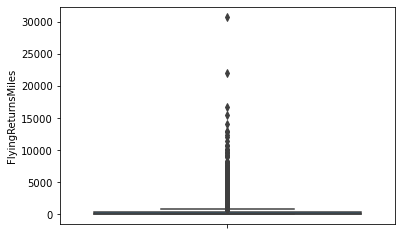

In [24]:
sns.boxplot(y=data['FlyingReturnsMiles'])

In [25]:
# Capping the outliers
Q1 = data["FlyingReturnsMiles"].quantile(0.25)
Q3 = data["FlyingReturnsMiles"].quantile(0.75)
IQR = Q3 - Q1
out_ls=[]
for i in data["FlyingReturnsMiles"]:
    if(i<Q1-(1.5*IQR)):
        i=Q1-(1.5*IQR)
        out_ls.append(i)
    elif (i>Q3+(1.5*IQR)):
        i=Q3+(1.5*IQR)
        out_ls.append(i)
    else:
        out_ls.append(i)

In [26]:
# Dropping the original column which had outliers and adding a new column with the capped values for the outliers.

data=data.drop(columns=["FlyingReturnsMiles"])
data["FlyingReturnsMiles"]=out_ls

<AxesSubplot:ylabel='FlyingReturnsMiles'>

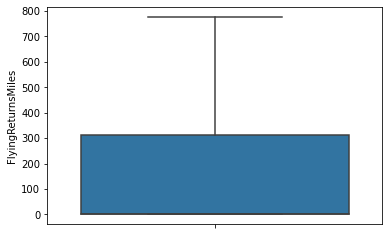

In [27]:
sns.boxplot(y=data['FlyingReturnsMiles'])

<AxesSubplot:ylabel='FlightTrans'>

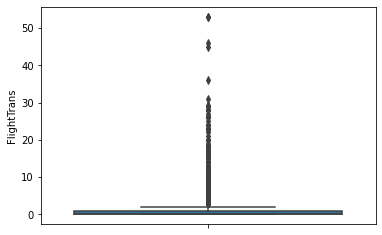

In [28]:
sns.boxplot(y=data['FlightTrans'])

In [29]:
# Capping the outliers
Q1 = data["FlightTrans"].quantile(0.25)
Q3 = data["FlightTrans"].quantile(0.75)
IQR = Q3 - Q1
out_ls=[]
for i in data["FlightTrans"]:
    if(i<Q1-(1.5*IQR)):
        i=Q1-(1.5*IQR)
        out_ls.append(i)
    elif (i>Q3+(1.5*IQR)):
        i=Q3+(1.5*IQR)
        out_ls.append(i)
    else:
        out_ls.append(i)

In [30]:
# Dropping the original column which had outliers and adding a new column with the capped values for the outliers.

data=data.drop(columns=["FlightTrans"])
data["FlightTrans"]=out_ls

<AxesSubplot:ylabel='FlightTrans'>

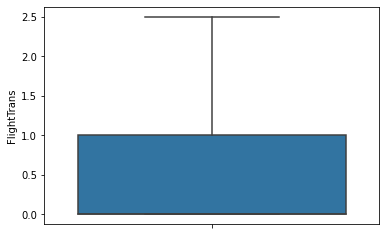

In [31]:
sns.boxplot(y=data['FlightTrans'])

<AxesSubplot:ylabel='EnrollDuration'>

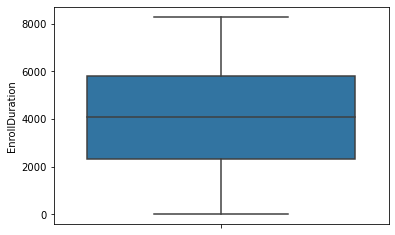

In [32]:
sns.boxplot(y=data['EnrollDuration'])

# EDA

In [33]:
# assigning a copy of the data
data1 = data.copy()

In [34]:
data1

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans
0,0,7000,28143.000,174.000,1.000,0.000,0.000
1,0,6968,19244.000,215.000,2.000,0.000,0.000
2,0,7034,41354.000,4123.000,4.000,0.000,0.000
3,0,6952,14776.000,500.000,1.000,0.000,0.000
4,0,6935,97752.000,43300.000,26.000,777.500,2.500
...,...,...,...,...,...,...,...
3994,0,1403,18476.000,8525.000,4.000,200.000,1.000
3995,0,1395,64385.000,981.000,5.000,0.000,0.000
3996,0,1402,73597.000,25447.000,8.000,0.000,0.000
3997,0,1401,54899.000,500.000,1.000,500.000,1.000


In [35]:
# units for the use of plots
units = [" miles","day",* ["miles"] * 2,"count" , " miles", "count"]
print(units)

[' miles', 'day', 'miles', 'miles', 'count', ' miles', 'count']


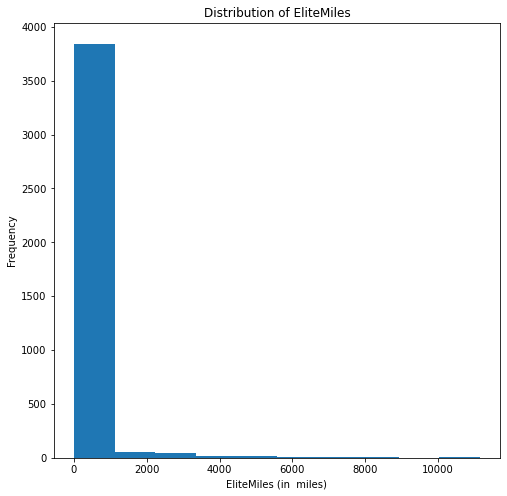

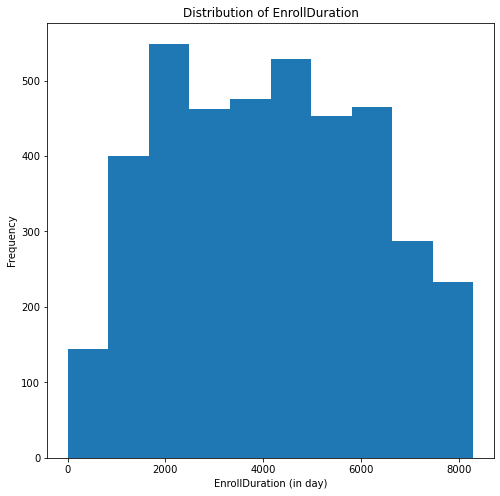

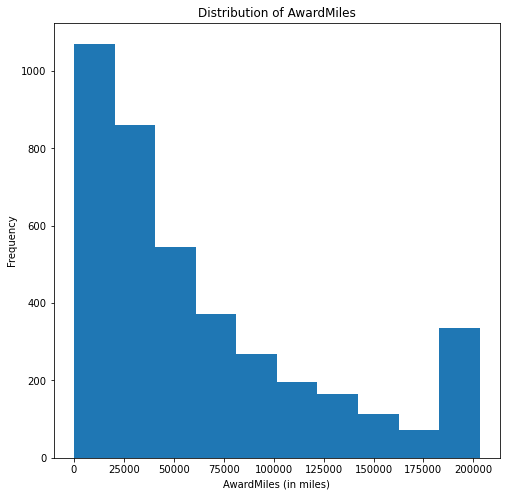

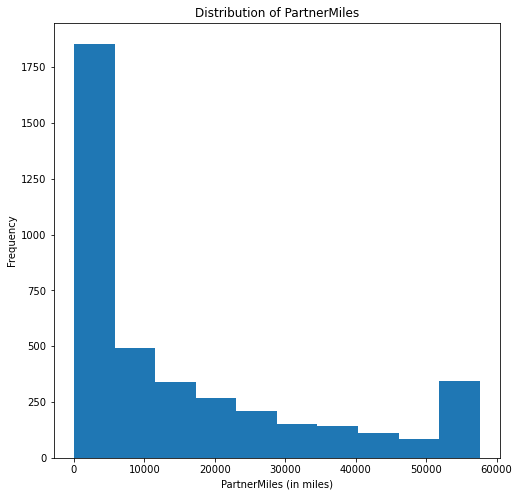

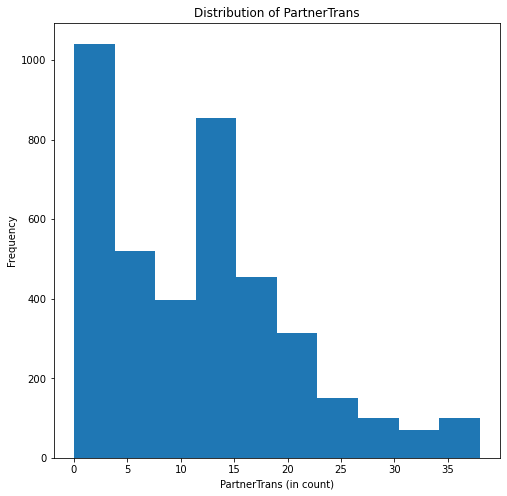

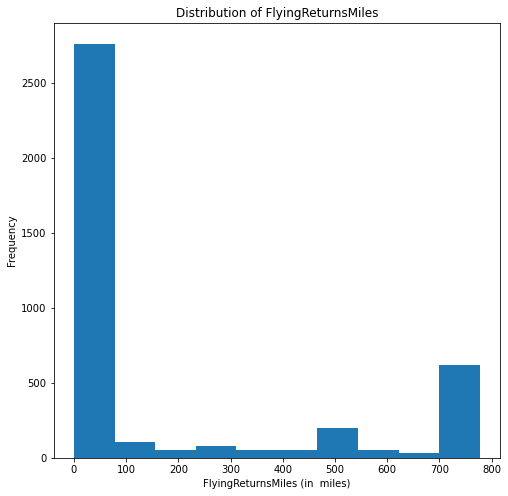

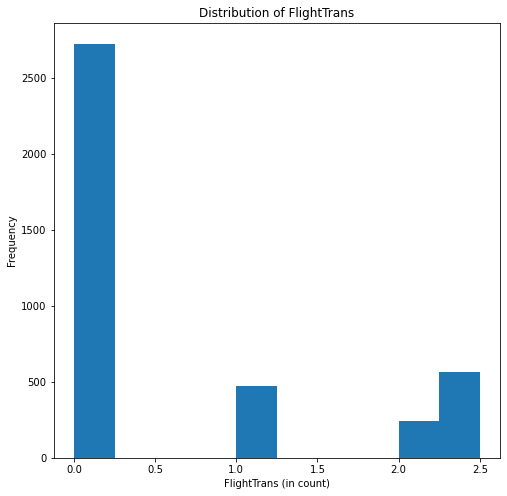

In [36]:
# distribution graph
for i in range(len(data1.columns)):
    data1[data1.columns[i]].plot(kind = "hist", bins = 10, figsize = (8, 8))
    plt.xlabel(f"{data1.columns[i]} (in {units[i]})")
    plt.title(f"Distribution of {data1.columns[i]}")
    plt.show()

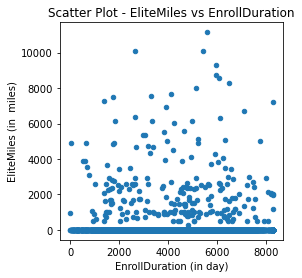

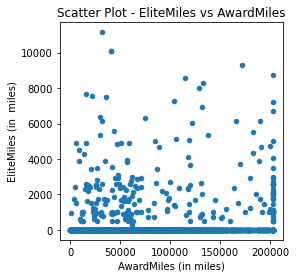

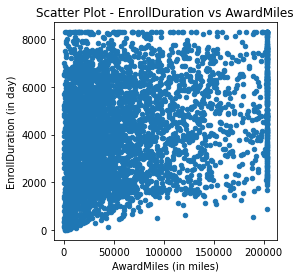

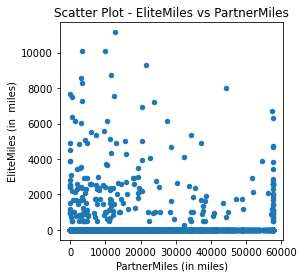

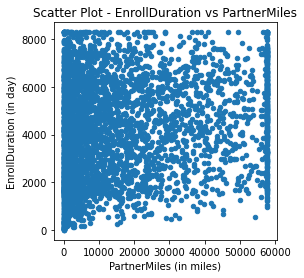

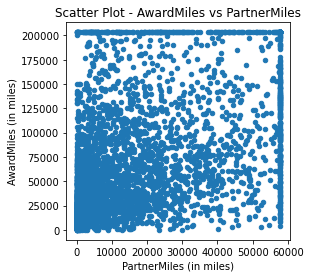

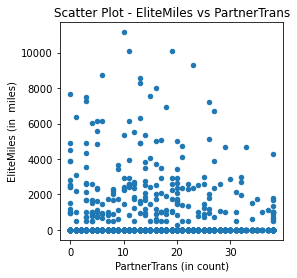

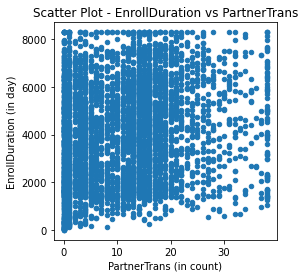

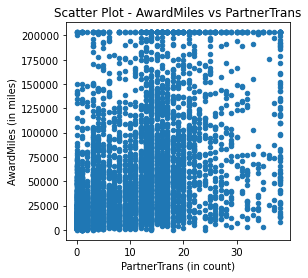

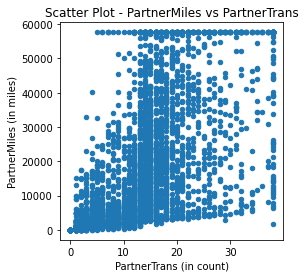

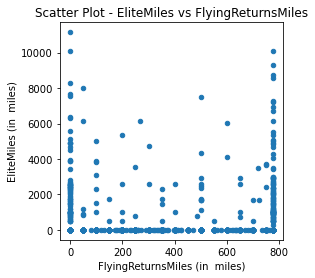

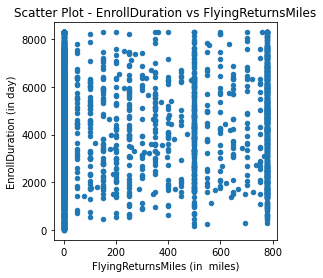

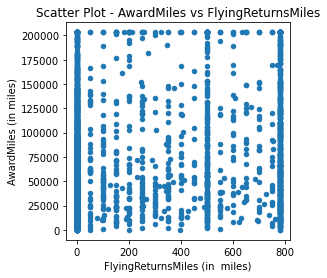

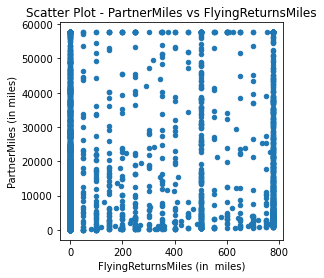

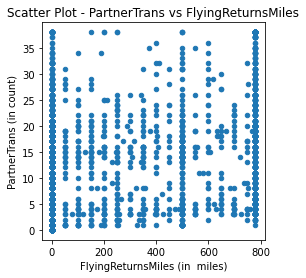

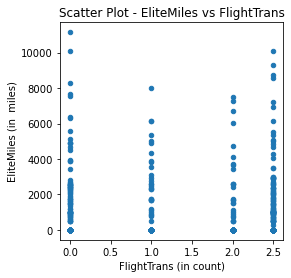

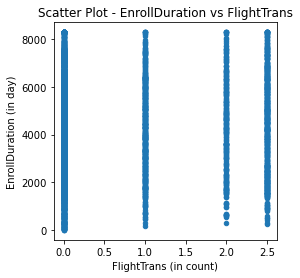

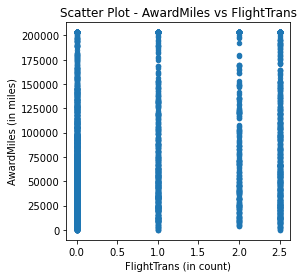

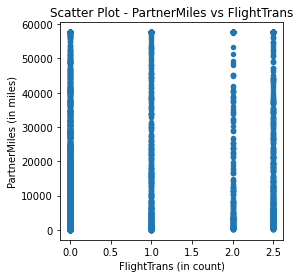

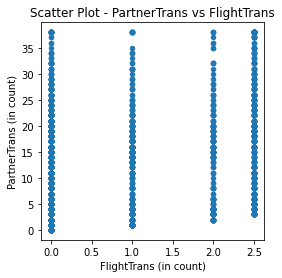

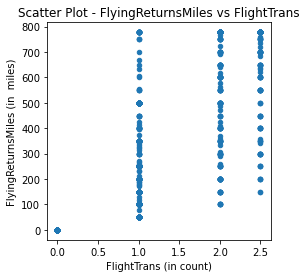

In [37]:
for i in range(len(data1.columns)):
    for j in range(i):
        data1.plot(x = data1.columns[i], y = data1.columns[j], kind = "scatter", figsize = (4,4))
        plt.xlabel(f"{data1.columns[i]} (in {units[i]})")
        plt.ylabel(f"{data1.columns[j]} (in {units[j]})")
        plt.title(f"Scatter Plot - {data1.columns[j]} vs {data1.columns[i]}")
        plt.show()

In [38]:
# to see correlation
data1.corr()

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans
EliteMiles,1.000,0.017,0.106,0.035,0.052,0.146,0.149
EnrollDuration,0.017,1.000,0.286,0.217,0.170,0.095,0.092
AwardMiles,0.106,0.286,1.000,0.494,0.409,0.297,0.296
PartnerMiles,0.035,0.217,0.494,1.000,0.664,0.206,0.194
PartnerTrans,0.052,0.170,0.409,0.664,1.000,0.311,0.309
FlyingReturnsMiles,0.146,0.095,0.297,0.206,0.311,1.000,0.943
FlightTrans,0.149,0.092,0.296,0.194,0.309,0.943,1.000


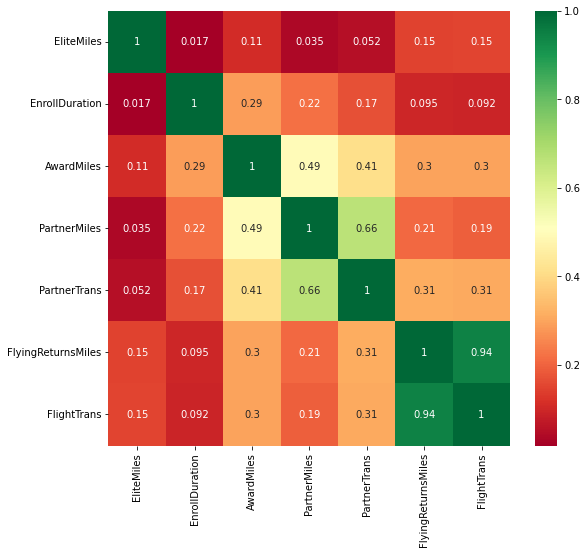

In [39]:
# heatmap for better inference
plt.figure(figsize=(9,8))
sns.heatmap(np.abs(data1.corr()),cmap = "RdYlGn",annot= True)
plt.show()

# Determining the optimal number of clusters using an elbow plot

In [40]:
from sklearn.preprocessing import StandardScaler  # to standardize the data
from sklearn.cluster import KMeans # to do k-means clustering

In [41]:
# standardizing the data
scaler = StandardScaler()
for col_name in data1.columns:
    data1[col_name] = scaler.fit_transform(np.array(data1[col_name]).reshape(-1, 1))
data1.head()

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans
0,-0.186,1.395,-0.607,-0.843,-1.149,-0.604,-0.626
1,-0.186,1.380,-0.759,-0.841,-1.039,-0.604,-0.626
2,-0.186,1.412,-0.382,-0.625,-0.820,-0.604,-0.626
3,-0.186,1.372,-0.835,-0.825,-1.149,-0.604,-0.626
4,-0.186,1.364,0.579,1.543,1.594,2.034,2.020


In [42]:
wcss = []
k = list(range(1, 11))
for i in k:
    kmeans_cluster = KMeans(n_clusters = i)
    kmeans_cluster.fit(data1)
    wcss.append(kmeans_cluster.inertia_)

Text(0.5, 1.0, 'Elbow Plot')

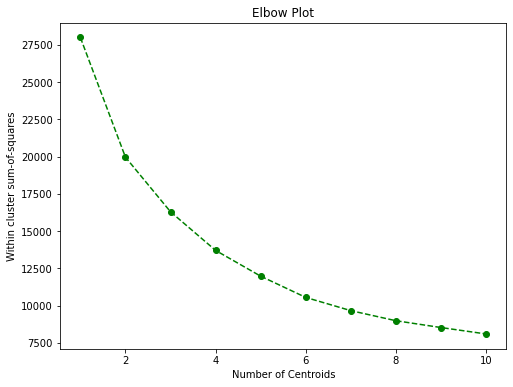

In [43]:
plt.figure(figsize = (8,6))
plt.plot(k, wcss, 'go--')
plt.xlabel('Number of Centroids')
plt.ylabel('Within cluster sum-of-squares')
plt.title('Elbow Plot')

Fitting the optimal clusters on data

In [51]:
kmeans_optimal = KMeans(n_clusters = 4)
kmeans_optimal.fit(data1)

KMeans(n_clusters=4)

In [52]:
y_pred = kmeans_optimal.predict(data1)
print(y_pred)

[3 3 3 ... 3 3 3]


In [53]:
data1['Cluster'] = y_pred + 1
data1.head()

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans,Cluster
0,-0.186,1.395,-0.607,-0.843,-1.149,-0.604,-0.626,4
1,-0.186,1.380,-0.759,-0.841,-1.039,-0.604,-0.626,4
2,-0.186,1.412,-0.382,-0.625,-0.820,-0.604,-0.626,4
3,-0.186,1.372,-0.835,-0.825,-1.149,-0.604,-0.626,4
4,-0.186,1.364,0.579,1.543,1.594,2.034,2.020,3


# Creating a dataframe of centroids for the cluster

In [54]:
kmeans_optimal.cluster_centers_

array([[-0.13780607,  0.46712848,  0.68772076,  0.93795458,  0.65740065,
        -0.45307041, -0.43983419,  2.        ],
       [ 6.62884247, -0.0136797 ,  0.62532133,  0.10893249,  0.19866573,
         0.86474032,  0.85414156,  3.        ],
       [ 0.00986132,  0.15297963,  0.51696334,  0.34059956,  0.57551074,
         1.70853529,  1.6943792 ,  4.        ],
       [-0.14128481, -0.29174922, -0.56899396, -0.60371977, -0.56489091,
        -0.50406217, -0.50443828,  1.        ]])

In [55]:
kmeans_optimal.feature_names_in_

array(['EliteMiles', 'EnrollDuration', 'AwardMiles', 'PartnerMiles',
       'PartnerTrans', 'FlyingReturnsMiles', 'FlightTrans', 'Cluster'],
      dtype=object)

In [56]:
centroids_data = pd.DataFrame(kmeans_optimal.cluster_centers_, columns = data1.columns,index = range(1, max(data1['Cluster']) + 1))
centroids_data

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans,Cluster
1,-0.138,0.467,0.688,0.938,0.657,-0.453,-0.440,2.000
2,6.629,-0.014,0.625,0.109,0.199,0.865,0.854,3.000
3,0.010,0.153,0.517,0.341,0.576,1.709,1.694,4.000
4,-0.141,-0.292,-0.569,-0.604,-0.565,-0.504,-0.504,1.000


Plotting the scatterplot labeled with clusters

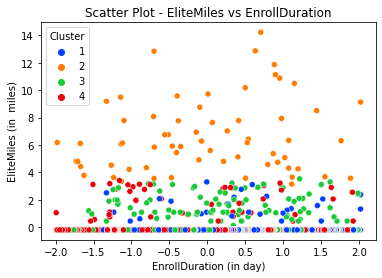

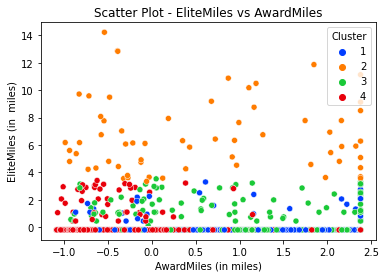

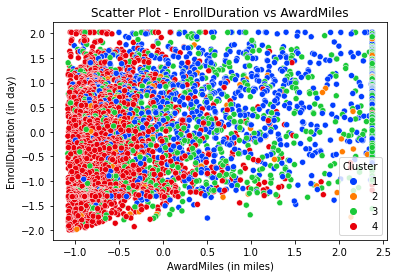

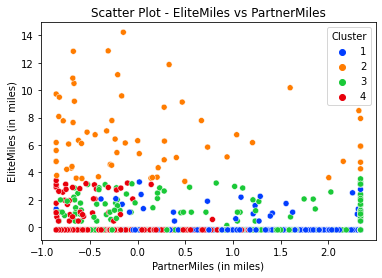

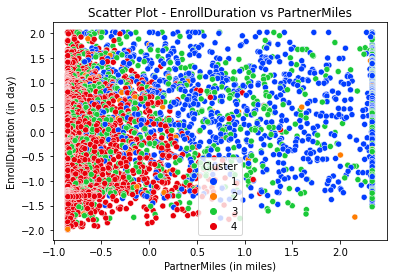

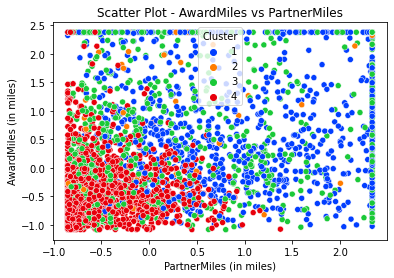

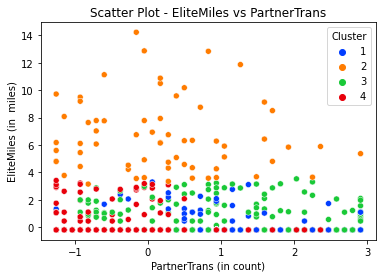

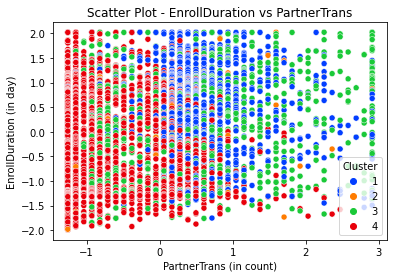

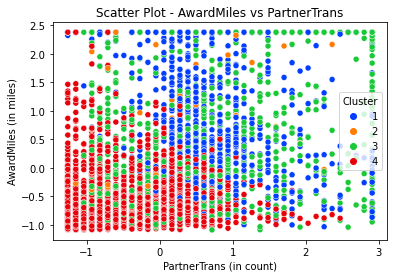

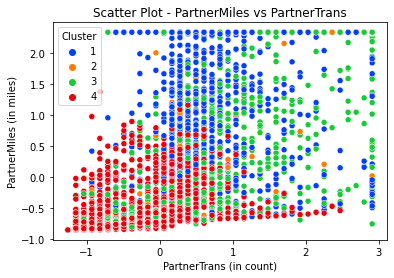

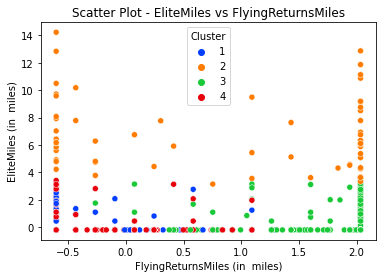

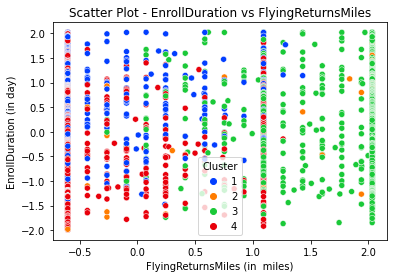

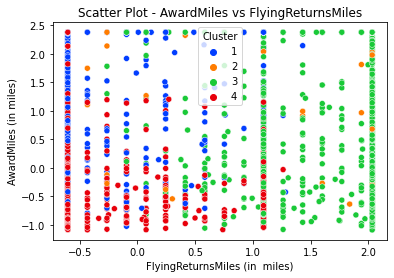

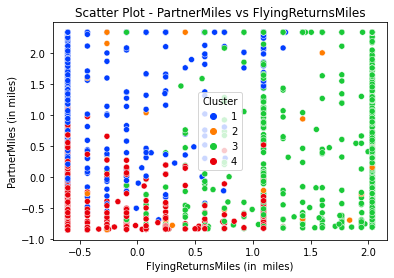

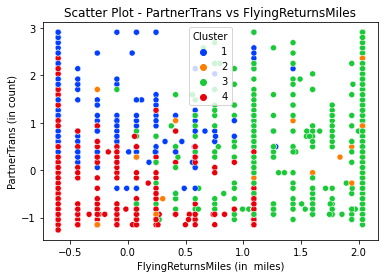

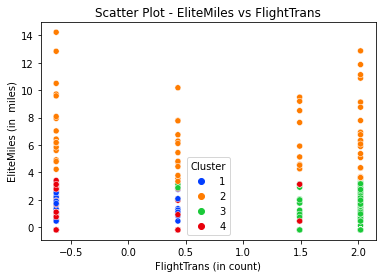

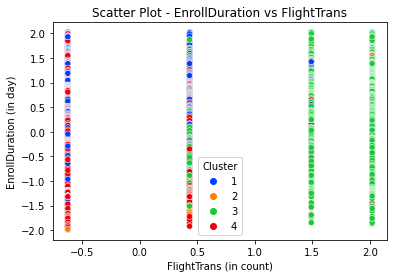

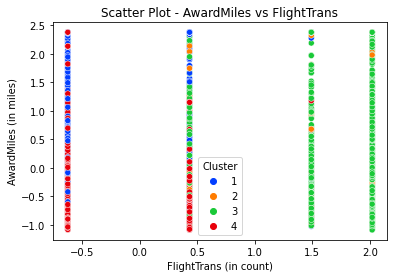

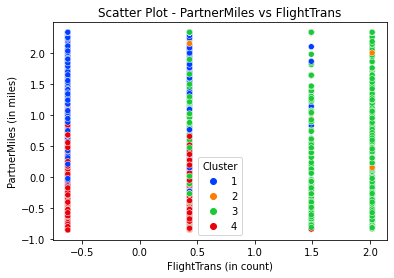

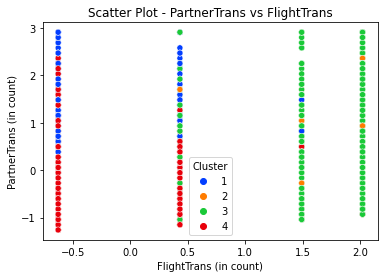

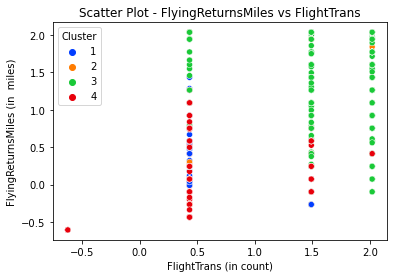

IndexError: list index out of range

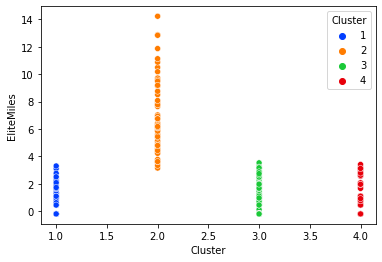

In [57]:
for i in range(len(data1.columns)):
    for j in range(i):
        sns.scatterplot(x = data1[data1.columns[i]], y = data1[data1.columns[j]], hue = data1["Cluster"], palette = "bright")
        plt.xlabel(f"{data1.columns[i]} (in {units[i]})")
        plt.ylabel(f"{data1.columns[j]} (in {units[j]})")
        plt.title(f"Scatter Plot - {data1.columns[j]} vs {data1.columns[i]}")
        plt.show()

In [58]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

(200, 2) (200,)


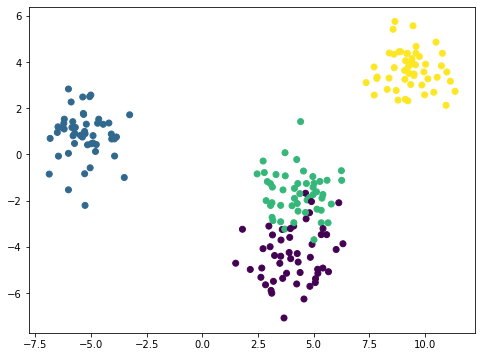

In [59]:
X, y = make_blobs(n_samples = 200, n_features = 2, centers = 4, random_state = 123)
print(X.shape, y.shape)
plt.figure(figsize = (8,6))
plt.scatter(X[:, 0], X[:, 1], c = y)

# clusters using dendograms

In [ ]:
cluster = linkage(X, method = 'ward')
plt.figure(figsize = (8,6))
dendrogram(cluster, labels = list(range(1, X.shape[0] + 1)))
plt.show()

In [ ]:
cluster = AgglomerativeClustering(n_clusters = 3, affinity = 'euclidean', linkage = 'ward')
cluster.fit_predict(X)

In [ ]:
plt.figure(figsize = (8,6))
plt.scatter(X[:, 0],X[:, 1], c = cluster.labels_)

# repeating the process to find the cluster for entire data

In [60]:
data.head()

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans
0,0,7000,28143.000,174.000,1.000,0.000,0.000
1,0,6968,19244.000,215.000,2.000,0.000,0.000
2,0,7034,41354.000,4123.000,4.000,0.000,0.000
3,0,6952,14776.000,500.000,1.000,0.000,0.000
4,0,6935,97752.000,43300.000,26.000,777.500,2.500


In [61]:
units = [" miles","day",* ["miles"] * 2,"count" , " miles", "count"]
print(units)

[' miles', 'day', 'miles', 'miles', 'count', ' miles', 'count']


In [62]:
data1 = data.copy()

In [63]:
# standarizing the data
scaler = StandardScaler()
for col_name in data1.columns:
    data1[col_name] = scaler.fit_transform(np.array(data1[col_name]).reshape(-1, 1))
data1.head()

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans
0,-0.186,1.395,-0.607,-0.843,-1.149,-0.604,-0.626
1,-0.186,1.380,-0.759,-0.841,-1.039,-0.604,-0.626
2,-0.186,1.412,-0.382,-0.625,-0.820,-0.604,-0.626
3,-0.186,1.372,-0.835,-0.825,-1.149,-0.604,-0.626
4,-0.186,1.364,0.579,1.543,1.594,2.034,2.020


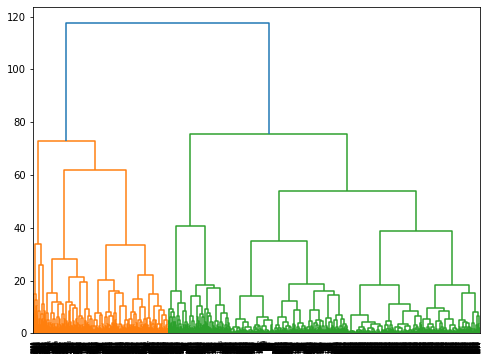

In [64]:
cluster = linkage(data1, method = 'ward')
plt.figure(figsize = (8,6))
dendrogram(cluster)
plt.show()

In [66]:
cluster = AgglomerativeClustering(n_clusters = 2, affinity = 'euclidean', linkage = 'ward')
cluster.fit_predict(data1)

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [67]:
data['Cluster'] = cluster.labels_ + 1

In [68]:
data.head()

,EliteMiles,EnrollDuration,AwardMiles,PartnerMiles,PartnerTrans,FlyingReturnsMiles,FlightTrans,Cluster
0,0,7000,28143.000,174.000,1.000,0.000,0.000,1
1,0,6968,19244.000,215.000,2.000,0.000,0.000,1
2,0,7034,41354.000,4123.000,4.000,0.000,0.000,1
3,0,6952,14776.000,500.000,1.000,0.000,0.000,1
4,0,6935,97752.000,43300.000,26.000,777.500,2.500,2


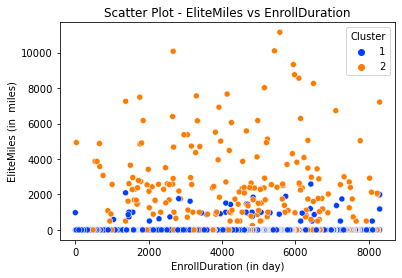

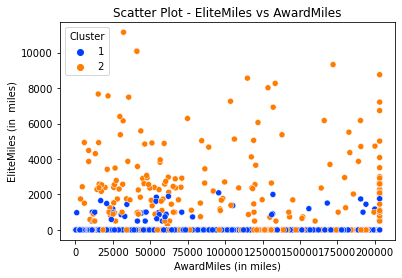

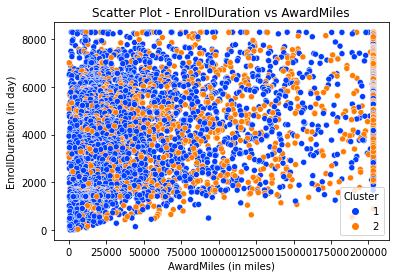

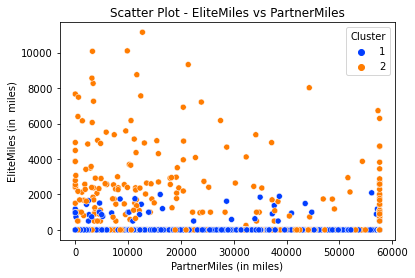

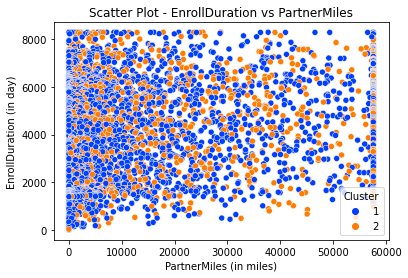

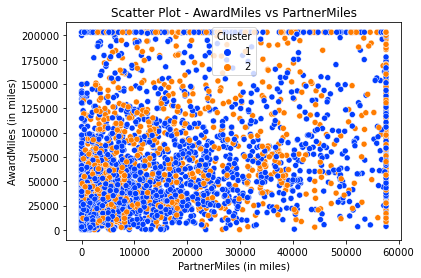

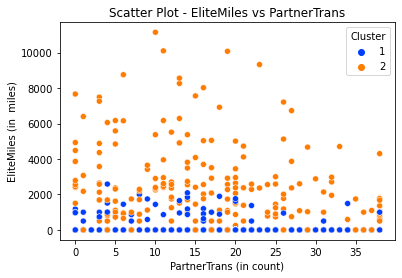

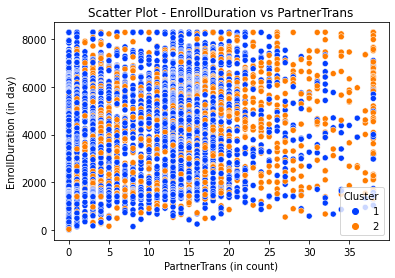

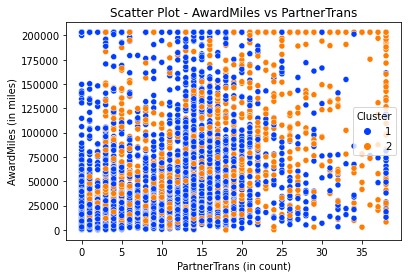

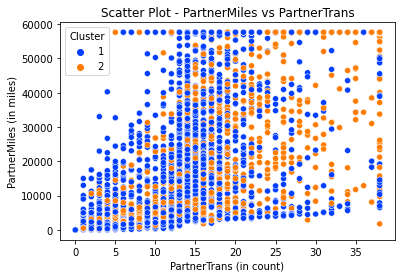

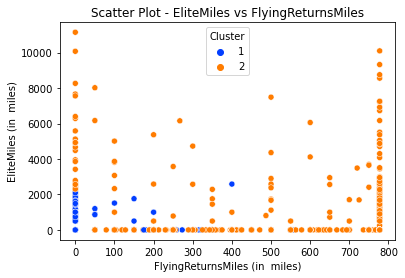

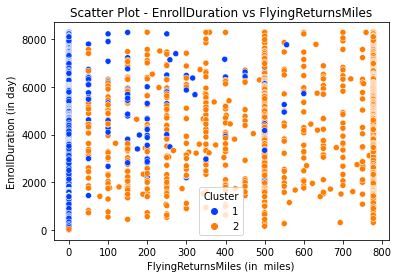

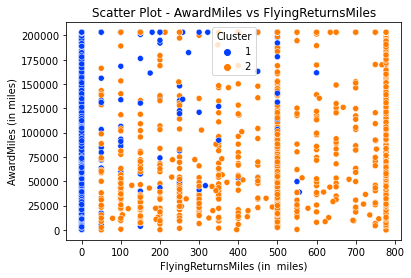

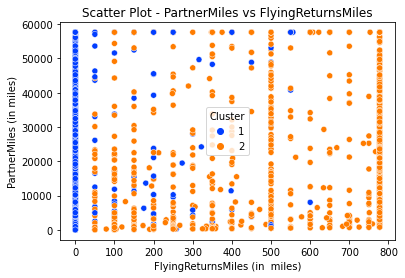

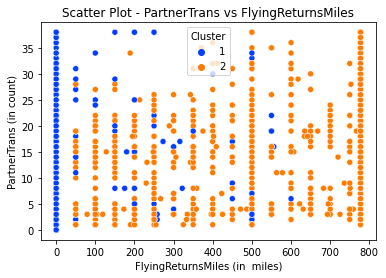

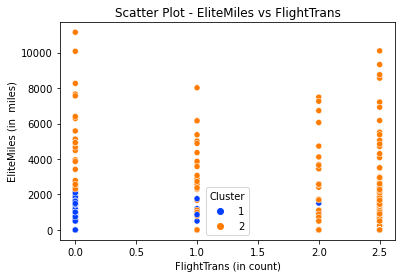

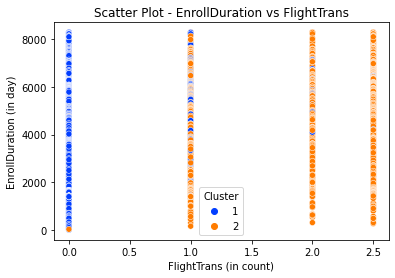

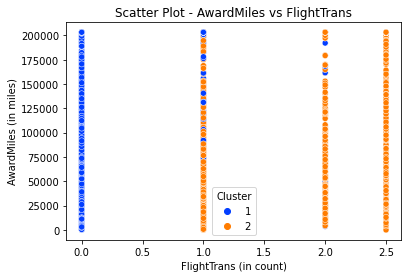

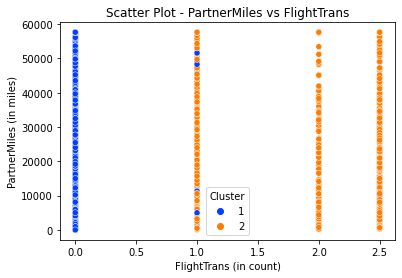

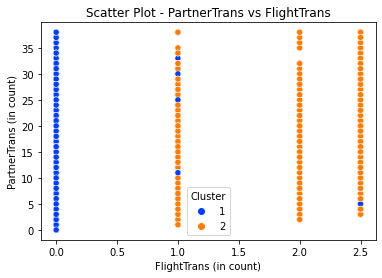

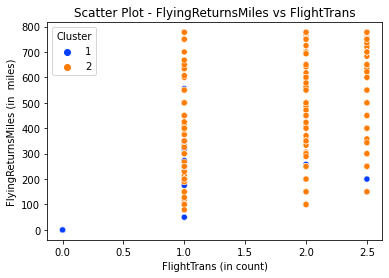

IndexError: list index out of range

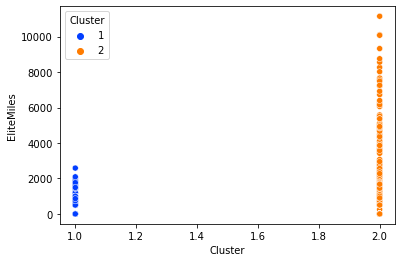

In [69]:
for i in range(len(data.columns)):
    for j in range(i):
        sns.scatterplot(x = data[data.columns[i]], y = data[data.columns[j]], hue = data["Cluster"], palette = "bright")
        plt.xlabel(f"{data.columns[i]} (in {units[i]})")
        plt.ylabel(f"{data.columns[j]} (in {units[j]})")
        plt.title(f"Scatter Plot - {data.columns[j]} vs {data.columns[i]}")
        plt.show()

<AxesSubplot:xlabel='Cluster', ylabel='AwardMiles'>

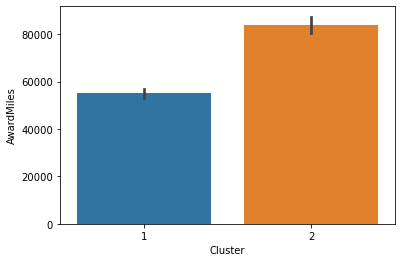

In [70]:
sns.barplot(data=data,x='Cluster',y='AwardMiles')

<AxesSubplot:xlabel='Cluster', ylabel='EliteMiles'>

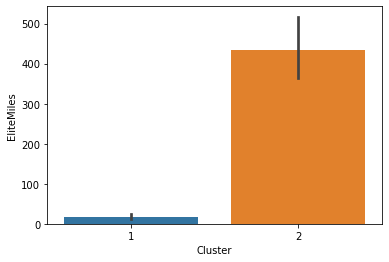

In [71]:
sns.barplot(data=data,x='Cluster',y='EliteMiles')

<AxesSubplot:xlabel='Cluster', ylabel='EnrollDuration'>

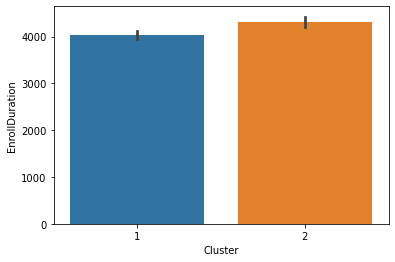

In [72]:
sns.barplot(data=data,x='Cluster',y='EnrollDuration')

<AxesSubplot:xlabel='Cluster', ylabel='PartnerMiles'>

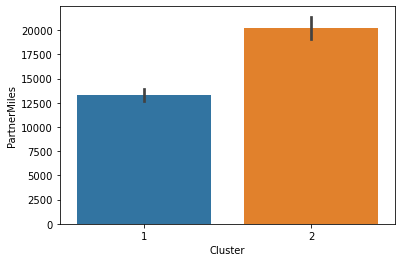

In [73]:
sns.barplot(data=data,x='Cluster',y='PartnerMiles')

<AxesSubplot:xlabel='Cluster', ylabel='FlyingReturnsMiles'>

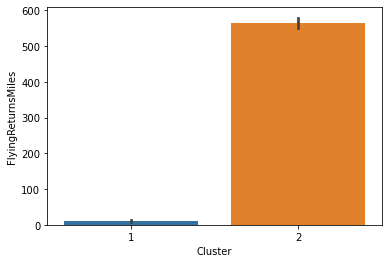

In [74]:
sns.barplot(data=data,x='Cluster',y='FlyingReturnsMiles')

<AxesSubplot:xlabel='Cluster', ylabel='FlightTrans'>

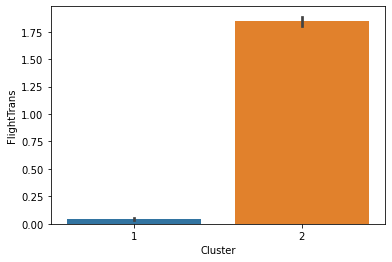

In [75]:
sns.barplot(data=data,x='Cluster',y='FlightTrans')

<AxesSubplot:xlabel='Cluster', ylabel='PartnerTrans'>

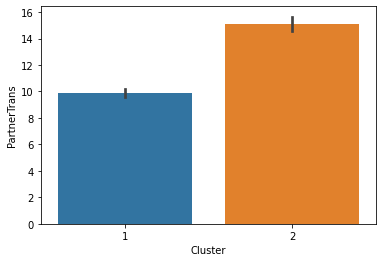

In [76]:
sns.barplot(data=data,x='Cluster',y='PartnerTrans')